# Лабораторная 2 — Детекция номеров на изображениях
В практически любой точке современного города человека окружает множество номеров и надписей.

**Ход работы:**

1. Обучить (или дообучить) нейронную сеть детектировать номера на изображениях. Номер — последовательность длиной до 20 символов из цифр, прописных и строчных букв русского или английского алфавита, знаков дефис и слеш.
2. Сфотографировать номера на улицах города (5–10 фотографий, не из интернета — проверка по картинкам). Кадры должны быть разнообразными: крупный / средний / дальний план.
3. Оценить качество детекции метриками IoU, Precision, Recall, mAP на тестовой части набора The Street View House Numbers (http://ufldl.stanford.edu/housenumbers/, есть на Roboflow в формате YOLO). Требуется **mAP ≥ 0.6**.
4. Детекцию можно улучшить, предобучив модель на датасете `university-of-toronto-xho85/numberdetection-eppfj` (Roboflow).
5. Сделать вывод.

**Пайплайн:** базовый `yolo11n` → **Stage A** предобучение на Roboflow number-detection → **Stage B** дообучение на SVHN + синтетика → оценка на SVHN-test → запуск на собственных уличных фото в `photos_jpeg/`.

---
## 1. Setup


In [1]:
%pip install -q roboflow ultralytics

import os, glob, getpass
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

RF_API_KEY = os.environ.get('ROBOFLOW_API_KEY')
if not RF_API_KEY:
    RF_API_KEY = getpass.getpass('Roboflow API key: ')
print('Roboflow API key set:', bool(RF_API_KEY))

Note: you may need to restart the kernel to use updated packages.
Torch: 2.5.1+cu121 | CUDA: True | NVIDIA GeForce RTX 4070 Laptop GPU


Roboflow API key:  ········


Roboflow API key set: True


Note: you may need to restart the kernel to use updated packages.


Torch: 2.5.1+cu121 | CUDA: True | NVIDIA GeForce RTX 4070 Laptop GPU
Roboflow API key set: True


---
## 2. Скачивание датасетов с Roboflow


In [2]:
import yaml
from roboflow import Roboflow

rf = Roboflow(api_key=RF_API_KEY)

numdet_ds = (rf.workspace('university-of-toronto-xho85')
               .project('numberdetection-eppfj')
               .version(2)
               .download('yolov11'))

svhn_ds = (rf.workspace('soumyadeep-dutta')
             .project('yolov5-svhn')
             .version(1)
             .download('yolov11'))

NUMDET_YAML = os.path.join(numdet_ds.location, 'data.yaml')
SVHN_YAML   = os.path.join(svhn_ds.location, 'data.yaml')

def normalize_yaml(yaml_path, location):
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = os.path.abspath(location)
    for split in ('train', 'val', 'test'):
        if os.path.isdir(os.path.join(location, split, 'images')):
            cfg[split] = f'{split}/images'
        elif split == 'val' and os.path.isdir(os.path.join(location, 'valid', 'images')):
            cfg[split] = 'valid/images'
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    return cfg

for name, p, loc in [('numberdetection', NUMDET_YAML, numdet_ds.location),
                     ('svhn', SVHN_YAML, svhn_ds.location)]:
    cfg = normalize_yaml(p, loc)
    print(f'{name}: {p}')
    print(f'   path={cfg.get("path")}')
    print(f'   train={cfg.get("train")} val={cfg.get("val")} test={cfg.get("test")}')
    print(f'   nc={cfg.get("nc")}  names={cfg.get("names")}')

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
numberdetection: /home/greg/git/uni/cv/Lab2/numberdetection-2/data.yaml
   path=/home/greg/git/uni/cv/Lab2/numberdetection-2
   train=train/images val=valid/images test=test/images
   nc=1  names=['number']
svhn: /home/greg/git/uni/cv/Lab2/YOLOv5-SVHN-1/data.yaml
   path=/home/greg/git/uni/cv/Lab2/YOLOv5-SVHN-1
   train=train/images val=valid/images test=test/images
   nc=1  names=['number']


loading Roboflow workspace...


loading Roboflow project...


numberdetection: /home/greg/git/uni/cv/Lab2/numberdetection-2/data.yaml
   path=/home/greg/git/uni/cv/Lab2/numberdetection-2
   train=train/images val=valid/images test=test/images
   nc=10  names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
svhn: /home/greg/git/uni/cv/Lab2/YOLOv5-SVHN-1/data.yaml
   path=/home/greg/git/uni/cv/Lab2/YOLOv5-SVHN-1
   train=train/images val=valid/images test=test/images
   nc=10  names=['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']


---
## 2b. Объединение per-digit меток в один бокс на номер


In [3]:
import glob, yaml

def _corners(b):
    xc, yc, w, h = b
    return (xc - w/2, yc - h/2, xc + w/2, yc + h/2)

def digits_to_sequences(boxes, gap_factor=0.7):
    if not boxes:
        return []
    items = []
    for b in boxes:
        x1, y1, x2, y2 = _corners(b)
        items.append({'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 'yc': b[1], 'h': b[3]})
    items.sort(key=lambda d: d['yc'])
    rows = [[items[0]]]
    for it in items[1:]:
        ref = rows[-1][-1]
        if it['yc'] - ref['yc'] < 0.5 * max(it['h'], ref['h']):
            rows[-1].append(it)
        else:
            rows.append([it])
    seqs = []
    for row in rows:
        row.sort(key=lambda d: d['x1'])
        cur = [row[0]]
        for prev, nxt in zip(row, row[1:]):
            if nxt['x1'] - prev['x2'] > gap_factor * max(prev['h'], nxt['h']):
                seqs.append(cur); cur = [nxt]
            else:
                cur.append(nxt)
        seqs.append(cur)
    out = []
    for s in seqs:
        x1 = min(d['x1'] for d in s); y1 = min(d['y1'] for d in s)
        x2 = max(d['x2'] for d in s); y2 = max(d['y2'] for d in s)
        out.append(((x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1))
    return out

def convert_dataset(location):
    sentinel = os.path.join(location, '.seq_converted')
    if os.path.exists(sentinel):
        print(f'  {os.path.basename(location)}: already converted, skipping')
        return
    n_files = n_seqs = 0
    for lbl in glob.glob(os.path.join(location, '*', 'labels', '*.txt')):
        boxes = []
        for line in open(lbl):
            p = line.split()
            if len(p) >= 5:
                boxes.append(tuple(map(float, p[1:5])))
        seqs = digits_to_sequences(boxes)
        with open(lbl, 'w') as f:
            for (xc, yc, w, h) in seqs:
                f.write(f'0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n')
        n_files += 1; n_seqs += len(seqs)
    yml = os.path.join(location, 'data.yaml')
    with open(yml) as f:
        cfg = yaml.safe_load(f)
    cfg['nc'] = 1; cfg['names'] = ['number']
    with open(yml, 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    open(sentinel, 'w').close()
    print(f'  {os.path.basename(location)}: {n_files} files -> {n_seqs} sequence boxes; data.yaml nc=1')

for loc in [numdet_ds.location, svhn_ds.location]:
    convert_dataset(loc)
print('Done: datasets now use a single "number" (sequence) class.')

  numberdetection-2: already converted, skipping
  YOLOv5-SVHN-1: already converted, skipping
Done: datasets now use a single "number" (sequence) class.


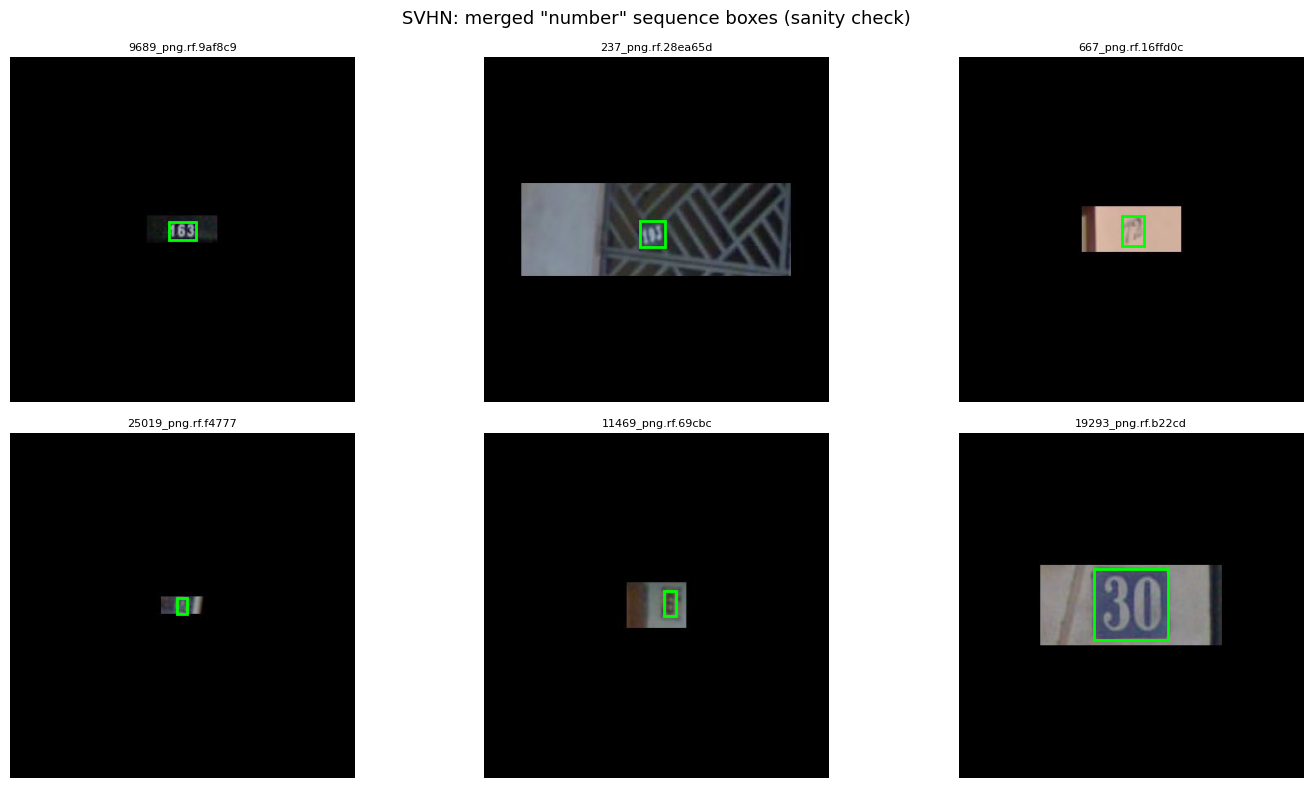

In [4]:
import random
import matplotlib.patches as patches

lbls = sorted(glob.glob(os.path.join(svhn_ds.location, 'train', 'labels', '*.txt')))
random.seed(0)
sample = random.sample(lbls, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('SVHN: merged "number" sequence boxes (sanity check)', fontsize=13)
for ax, lbl in zip(axes.flat, sample):
    cand = glob.glob(lbl.replace(os.sep + 'labels' + os.sep, os.sep + 'images' + os.sep)[:-4] + '.*')
    img = cv2.cvtColor(cv2.imread(cand[0]), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    for line in open(lbl):
        p = line.split()
        if len(p) < 5:
            continue
        xc, yc, w, h = map(float, p[1:5])
        ax.add_patch(patches.Rectangle(((xc - w/2) * W, (yc - h/2) * H), w * W, h * H,
                                       fill=False, edgecolor='lime', linewidth=2))
    ax.set_title(os.path.basename(cand[0])[:18], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 2d. Синтетика: русские составные номера на реальных фасадах (CMP, v10)


In [5]:
import os, random, glob, yaml, zipfile, urllib.request, shutil
import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont

try:
    from faker import Faker
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'faker'], check=True)
    from faker import Faker
_faker = Faker('ru_RU')

def _street_name(rng):
    name = _faker.street_name()
    if rng.random() < 0.5:
        name = name.upper()
    return name

SYN_DIR = 'synthetic_rus_numbers'
CMP_DIR = 'cmp_facade'
CMP_URL = 'https://cmp.felk.cvut.cz/~tylecr1/facade/CMP_facade_DB_base.zip'
N_TRAIN, N_VAL = 2000, 400
RU_LIT = list('АБВГ')
FONTS = [c for c in [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSerif-Bold.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf',
    '/usr/share/fonts/truetype/noto/NotoSansMono-Regular.ttf',
] if os.path.exists(c)]
assert FONTS, 'no Cyrillic-capable fonts found'

def ensure_backgrounds():
    if glob.glob(f'{CMP_DIR}/**/*.jpg', recursive=True):
        return
    os.makedirs(CMP_DIR, exist_ok=True)
    zp = os.path.join(CMP_DIR, 'base.zip')
    print(f'  downloading CMP Facade from {CMP_URL} ...')
    urllib.request.urlretrieve(CMP_URL, zp)
    with zipfile.ZipFile(zp) as zf: zf.extractall(CMP_DIR)
    os.remove(zp)
    print(f'  CMP extracted: {len(glob.glob(f"{CMP_DIR}/**/*.jpg", recursive=True))} jpg backgrounds')


def _apply_rotation(rng, img, box, max_deg=15):
    H, W = img.shape[:2]
    ang = rng.uniform(-max_deg, max_deg)
    M = cv2.getRotationMatrix2D((W / 2, H / 2), ang, 1.0)
    img_rot = cv2.warpAffine(img, M, (W, H), borderMode=cv2.BORDER_REPLICATE)
    if box is None:
        return img_rot, None
    xc, yc, w, h = box
    x1, y1, x2, y2 = (xc - w/2)*W, (yc - h/2)*H, (xc + w/2)*W, (yc + h/2)*H
    pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], np.float32).reshape(-1, 1, 2)
    new = cv2.transform(pts, M).reshape(-1, 2)
    nx1, ny1 = max(0, new[:, 0].min()), max(0, new[:, 1].min())
    nx2, ny2 = min(W - 1, new[:, 0].max()), min(H - 1, new[:, 1].max())
    return img_rot, ((nx1 + nx2) / 2 / W, (ny1 + ny2) / 2 / H, (nx2 - nx1) / W, (ny2 - ny1) / H)

def _apply_perspective(rng, img, box, max_angle_deg=50.0, kind=None):
    H, W = img.shape[:2]
    ang_deg = rng.uniform(max_angle_deg * 0.4, max_angle_deg)
    s = 1.0 - float(np.cos(np.radians(ang_deg)))
    src = np.array([[0, 0], [W, 0], [W, H], [0, H]], np.float32)
    dx, dy = s * W, s * H
    if kind is None:
        kind = rng.choice(['up', 'down', 'left', 'right'])
    if kind == 'up':
        dst = np.array([[dx, 0], [W - dx, 0], [W, H], [0, H]], np.float32)
    elif kind == 'down':
        dst = np.array([[0, 0], [W, 0], [W - dx, H], [dx, H]], np.float32)
    elif kind == 'left':
        dst = np.array([[0, dy], [W, 0], [W, H], [0, H - dy]], np.float32)
    else:
        dst = np.array([[0, 0], [W, dy], [W, H - dy], [0, H]], np.float32)
    Hm = cv2.getPerspectiveTransform(src, dst)
    img_w = cv2.warpPerspective(img, Hm, (W, H), borderMode=cv2.BORDER_REPLICATE)
    if box is None:
        return img_w, None
    xc, yc, w, h = box
    x1, y1, x2, y2 = (xc - w/2)*W, (yc - h/2)*H, (xc + w/2)*W, (yc + h/2)*H
    pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], np.float32).reshape(-1, 1, 2)
    new = cv2.perspectiveTransform(pts, Hm).reshape(-1, 2)
    nx1, ny1 = max(0, new[:, 0].min()), max(0, new[:, 1].min())
    nx2, ny2 = min(W - 1, new[:, 0].max()), min(H - 1, new[:, 1].max())
    return img_w, ((nx1 + nx2) / 2 / W, (ny1 + ny2) / 2 / H, (nx2 - nx1) / W, (ny2 - ny1) / H)

def compose_number(rng):
    dom = rng.randint(1, 199)
    head = f'{dom}{rng.choice(RU_LIT)}' if rng.random() < 0.25 else str(dom)
    parts = [head]
    if rng.random() < 0.5:
        k = rng.randint(1, 15); parts.append(rng.choice([f'к{k}', f'к.{k}', f'корп.{k}']))
    if rng.random() < 0.4:
        s = rng.randint(1, 9); parts.append(rng.choice([f'стр{s}', f'стр.{s}']))
    text = ' '.join(parts); st = rng.random()
    if st < 0.15: text = f'{dom}/{rng.randint(1, 9)}'
    elif st < 0.25: text = f'{dom}-{rng.randint(1, 9)}'
    return text[:20]

def random_bg(rng, bg_paths):
    img = None
    for _ in range(5):
        img = cv2.imread(rng.choice(bg_paths))
        if img is not None: break
    H, W = img.shape[:2]
    short = rng.randint(280, 420); aspect = rng.uniform(0.7, 1.7)
    cw, ch = min(int(short * aspect), W), min(int(short / aspect), H)
    cx = rng.randint(0, max(0, W - cw)); cy = rng.randint(0, max(0, H - ch))
    crop = img[cy:cy + ch, cx:cx + cw].copy()
    if rng.random() < 0.5:
        crop = np.clip(crop.astype(np.float32) * rng.uniform(0.75, 1.15) + rng.uniform(-15, 15),
                       0, 255).astype(np.uint8)
    return crop

def render_plate_on(rng, bg):
    text = compose_number(rng)
    font = ImageFont.truetype(rng.choice(FONTS), rng.randint(28, 56))
    l, t, r, b = ImageDraw.Draw(Image.new('RGB', (10, 10))).textbbox((0, 0), text, font=font)
    tw, th = r - l, b - t
    pad = rng.randint(6, 18)
    schemes = [((0, 40, 104), (255, 255, 255)),
               ((20, 30, 60),  (240, 240, 210)),
               ((10, 25, 80),  (250, 250, 250))]
    bgc, fgc = rng.choice(schemes)
    pw, ph = tw + 2 * pad, th + 2 * pad
    H, W = bg.shape[:2]
    if pw >= W - 4 or ph >= H - 4: return None
    plate = Image.new('RGB', (pw, ph), bgc); pd = ImageDraw.Draw(plate)
    if rng.random() < 0.35:
        pd.rectangle([1, 1, pw - 2, ph - 2], outline=fgc, width=max(1, ph // 22))
    pd.text((pad - l, pad - t), text, font=font, fill=fgc)
    px, py = rng.randint(2, W - pw - 2), rng.randint(2, H - ph - 2)
    out = bg.copy()
    out[py:py + ph, px:px + pw] = np.array(plate)[:, :, ::-1]
    bx1, by1, bx2, by2 = px + pad, py + pad, px + pad + tw, py + pad + th
    return out, ((bx1 + bx2) / 2 / W, (by1 + by2) / 2 / H, (bx2 - bx1) / W, (by2 - by1) / H), text


def render_street_plate(rng, bg):
    line1 = _street_name(rng)
    num = compose_number(rng)
    schemes = [((0, 40, 104), (255, 255, 255)),
               ((20, 25, 50), (240, 240, 220)),
               ((10, 25, 80), (250, 250, 250))]
    bgc, fgc = rng.choice(schemes)
    f_name = ImageFont.truetype(rng.choice(FONTS), rng.randint(20, 32))
    f_num  = ImageFont.truetype(rng.choice(FONTS), rng.randint(28, 46))
    d = ImageDraw.Draw(Image.new('RGB', (10, 10)))
    nl, nt, nr, nb = d.textbbox((0, 0), line1, font=f_name); nw, nh = nr - nl, nb - nt
    dl, dt, dr, db = d.textbbox((0, 0), num,  font=f_num);   dw, dh = dr - dl, db - dt
    pad = rng.randint(8, 16); gap = rng.randint(8, 16)
    if rng.choice(['h', 'v']) == 'h':
        pw = pad + nw + gap + dw + pad; ph = pad + max(nh, dh) + pad
        n_pos = (pad - nl, pad + (max(nh, dh) - nh) // 2 - nt)
        sub_x1 = pad + nw + gap; sub_y1 = pad + (max(nh, dh) - dh) // 2
    else:
        pw = pad + max(nw, dw) + pad; ph = pad + nh + gap + dh + pad
        n_pos = (pad + (max(nw, dw) - nw) // 2 - nl, pad - nt)
        sub_x1 = pad + (max(nw, dw) - dw) // 2; sub_y1 = pad + nh + gap
    sub_x2, sub_y2 = sub_x1 + dw, sub_y1 + dh
    num_pos = (sub_x1 - dl, sub_y1 - dt)
    H, W = bg.shape[:2]
    if pw >= W - 4 or ph >= H - 4 or pw < 60 or ph < 40: return None
    plate = Image.new('RGB', (pw, ph), bgc); pd = ImageDraw.Draw(plate)
    if rng.random() < 0.5:
        pd.rectangle([1, 1, pw - 2, ph - 2], outline=fgc, width=max(1, ph // 30))
    pd.text(n_pos, line1, font=f_name, fill=fgc)
    sub_pad = rng.randint(2, 5)
    sx1, sy1 = sub_x1 - sub_pad, sub_y1 - sub_pad
    sx2, sy2 = sub_x2 + sub_pad, sub_y2 + sub_pad
    pd.rectangle([sx1, sy1, sx2, sy2], fill=fgc)
    pd.text(num_pos, num, font=f_num, fill=bgc)
    px, py = rng.randint(2, W - pw - 2), rng.randint(2, H - ph - 2)
    out = bg.copy()
    out[py:py + ph, px:px + pw] = np.array(plate)[:, :, ::-1]
    bx1, by1, bx2, by2 = px + sx1, py + sy1, px + sx2, py + sy2
    return out, ((bx1 + bx2) / 2 / W, (by1 + by2) / 2 / H, (bx2 - bx1) / W, (by2 - by1) / H), num


def render_hard_negative(rng, bg):
    H, W = bg.shape[:2]
    out = bg.copy()
    kind = rng.choice(['blank_plate', 'mesh', 'window_grid', 'circle_sign', 'cctv', 'pipe'])
    if kind == 'blank_plate':
        pw = rng.randint(60, min(180, W - 6))
        ph = rng.randint(25, min(80, H - 6, pw))
        col = rng.choice([(0, 40, 104), (20, 25, 50), (40, 40, 50), (220, 220, 220)])
        px, py = rng.randint(2, W - pw - 2), rng.randint(2, H - ph - 2)
        cv2.rectangle(out, (px, py), (px + pw, py + ph), col, -1)
        if rng.random() < 0.4:
            edge = tuple(255 - c for c in col)
            cv2.rectangle(out, (px, py), (px + pw, py + ph), edge, max(1, ph // 25))
    elif kind == 'mesh':
        rw = rng.randint(80, min(220, W - 6)); rh = rng.randint(40, min(120, H - 6))
        rx, ry = rng.randint(2, W - rw - 2), rng.randint(2, H - rh - 2)
        col = (180, 180, 180) if rng.random() < 0.5 else (60, 60, 60)
        step = rng.randint(8, 16)
        for y in range(0, rh, step):
            cv2.line(out, (rx, ry + y), (rx + rw, ry + y), col, 1)
        for x in range(0, rw, step):
            cv2.line(out, (rx + x, ry), (rx + x, ry + rh), col, 1)
        if rng.random() < 0.5:
            for off in range(-rh, rw, step):
                cv2.line(out, (rx + off, ry), (rx + off + rh, ry + rh), col, 1)
    elif kind == 'window_grid':
        cols, rows = rng.choice([(2, 2), (3, 2), (2, 3)])
        cw, ch = rng.randint(25, 50), rng.randint(30, 60)
        gap = rng.randint(3, 8)
        gw = cols * cw + (cols + 1) * gap; gh = rows * ch + (rows + 1) * gap
        if gw < W - 6 and gh < H - 6:
            gx, gy = rng.randint(2, W - gw - 2), rng.randint(2, H - gh - 2)
            frame_col = (40, 40, 40)
            cv2.rectangle(out, (gx, gy), (gx + gw, gy + gh), frame_col, -1)
            for r in range(rows):
                for c in range(cols):
                    px = gx + gap + c * (cw + gap); py = gy + gap + r * (ch + gap)
                    pane = (rng.randint(60, 130),) * 3
                    cv2.rectangle(out, (px, py), (px + cw, py + ch), pane, -1)
    elif kind == 'circle_sign':
        r = rng.randint(25, min(60, W // 4, H // 4))
        cx, cy = rng.randint(r + 2, W - r - 2), rng.randint(r + 2, H - r - 2)
        rim = rng.choice([(255, 60, 60), (60, 60, 200), (0, 40, 104)])
        cv2.circle(out, (cx, cy), r, rim, -1)
        cv2.circle(out, (cx, cy), int(r * 0.75), (240, 240, 240), -1)
    elif kind == 'cctv':
        bw = rng.randint(40, 90); bh = rng.randint(25, 55)
        if bw < W - 6 and bh < H - 6:
            bx, by = rng.randint(2, W - bw - 2), rng.randint(2, H - bh - 2)
            body = (230, 230, 230) if rng.random() < 0.5 else (40, 40, 40)
            cv2.rectangle(out, (bx, by), (bx + bw, by + bh), body, -1)
            lens = (10, 10, 10)
            cv2.circle(out, (bx + int(0.8 * bw), by + bh // 2), max(4, bh // 4), lens, -1)
    else:
        if rng.random() < 0.5:
            pw = rng.randint(8, 22); ph = rng.randint(80, H - 6)
        else:
            pw = rng.randint(80, W - 6); ph = rng.randint(8, 22)
        if pw < W - 4 and ph < H - 4:
            px, py = rng.randint(2, W - pw - 2), rng.randint(2, H - ph - 2)
            mid = (190, 190, 190); edge = (110, 110, 110)
            cv2.rectangle(out, (px, py), (px + pw, py + ph), mid, -1)
            cv2.rectangle(out, (px, py), (px + pw, py + ph), edge, 2)
    return out

def make_sample(rng, bg_paths):
    bg = random_bg(rng, bg_paths)
    m = rng.random()
    if m < 0.20:
        img, box = bg, None
    elif m < 0.40:
        img, box = render_hard_negative(rng, bg), None
    elif m < 0.70:
        r = render_street_plate(rng, bg) or render_plate_on(rng, bg)
        img, box = (r[0], r[1]) if r else (bg, None)
    else:
        r = render_plate_on(rng, bg) or render_street_plate(rng, bg)
        img, box = (r[0], r[1]) if r else (bg, None)
    if rng.random() < 0.70:
        img, box = _apply_rotation(rng, img, box, max_deg=15)
    if rng.random() < 0.55:
        img, box = _apply_perspective(rng, img, box, max_angle_deg=50)
    return img, box

def build_synthetic():
    if os.path.exists(os.path.join(SYN_DIR, '.done_v10')):
        print(f'  {SYN_DIR}: already generated (v10), skipping'); return
    if os.path.isdir(SYN_DIR):
        shutil.rmtree(SYN_DIR); print('  removed old synthetic_rus_numbers (older)')
    ensure_backgrounds()
    bgs = sorted(glob.glob(f'{CMP_DIR}/**/*.jpg', recursive=True))
    assert bgs, 'no CMP backgrounds found'
    rng = random.Random(42); np.random.seed(42); _faker.seed_instance(42)
    n_pos = n_neg = 0
    for split, n in [('train', N_TRAIN), ('valid', N_VAL)]:
        idir, ldir = os.path.join(SYN_DIR, split, 'images'), os.path.join(SYN_DIR, split, 'labels')
        os.makedirs(idir, exist_ok=True); os.makedirs(ldir, exist_ok=True)
        for i in range(n):
            img, box = make_sample(rng, bgs)
            cv2.imwrite(os.path.join(idir, f'{i:05d}.jpg'), img)
            with open(os.path.join(ldir, f'{i:05d}.txt'), 'w') as f:
                if box is not None:
                    f.write('0 %.6f %.6f %.6f %.6f\n' % box); n_pos += 1
                else:
                    n_neg += 1
    with open(os.path.join(SYN_DIR, 'data.yaml'), 'w') as f:
        yaml.safe_dump({'path': os.path.abspath(SYN_DIR), 'train': 'train/images',
                        'val': 'valid/images', 'nc': 1, 'names': ['number']}, f, sort_keys=False)
    open(os.path.join(SYN_DIR, '.done_v10'), 'w').close()
    print(f'  {SYN_DIR}: {n_pos} positives + {n_neg} negatives = {n_pos + n_neg} images (CMP backgrounds)')

build_synthetic()
SYN_YAML = os.path.join(SYN_DIR, 'data.yaml')
print('Synthetic dataset ready:', SYN_YAML)

  synthetic_rus_numbers: already generated (v10), skipping
Synthetic dataset ready: synthetic_rus_numbers/data.yaml


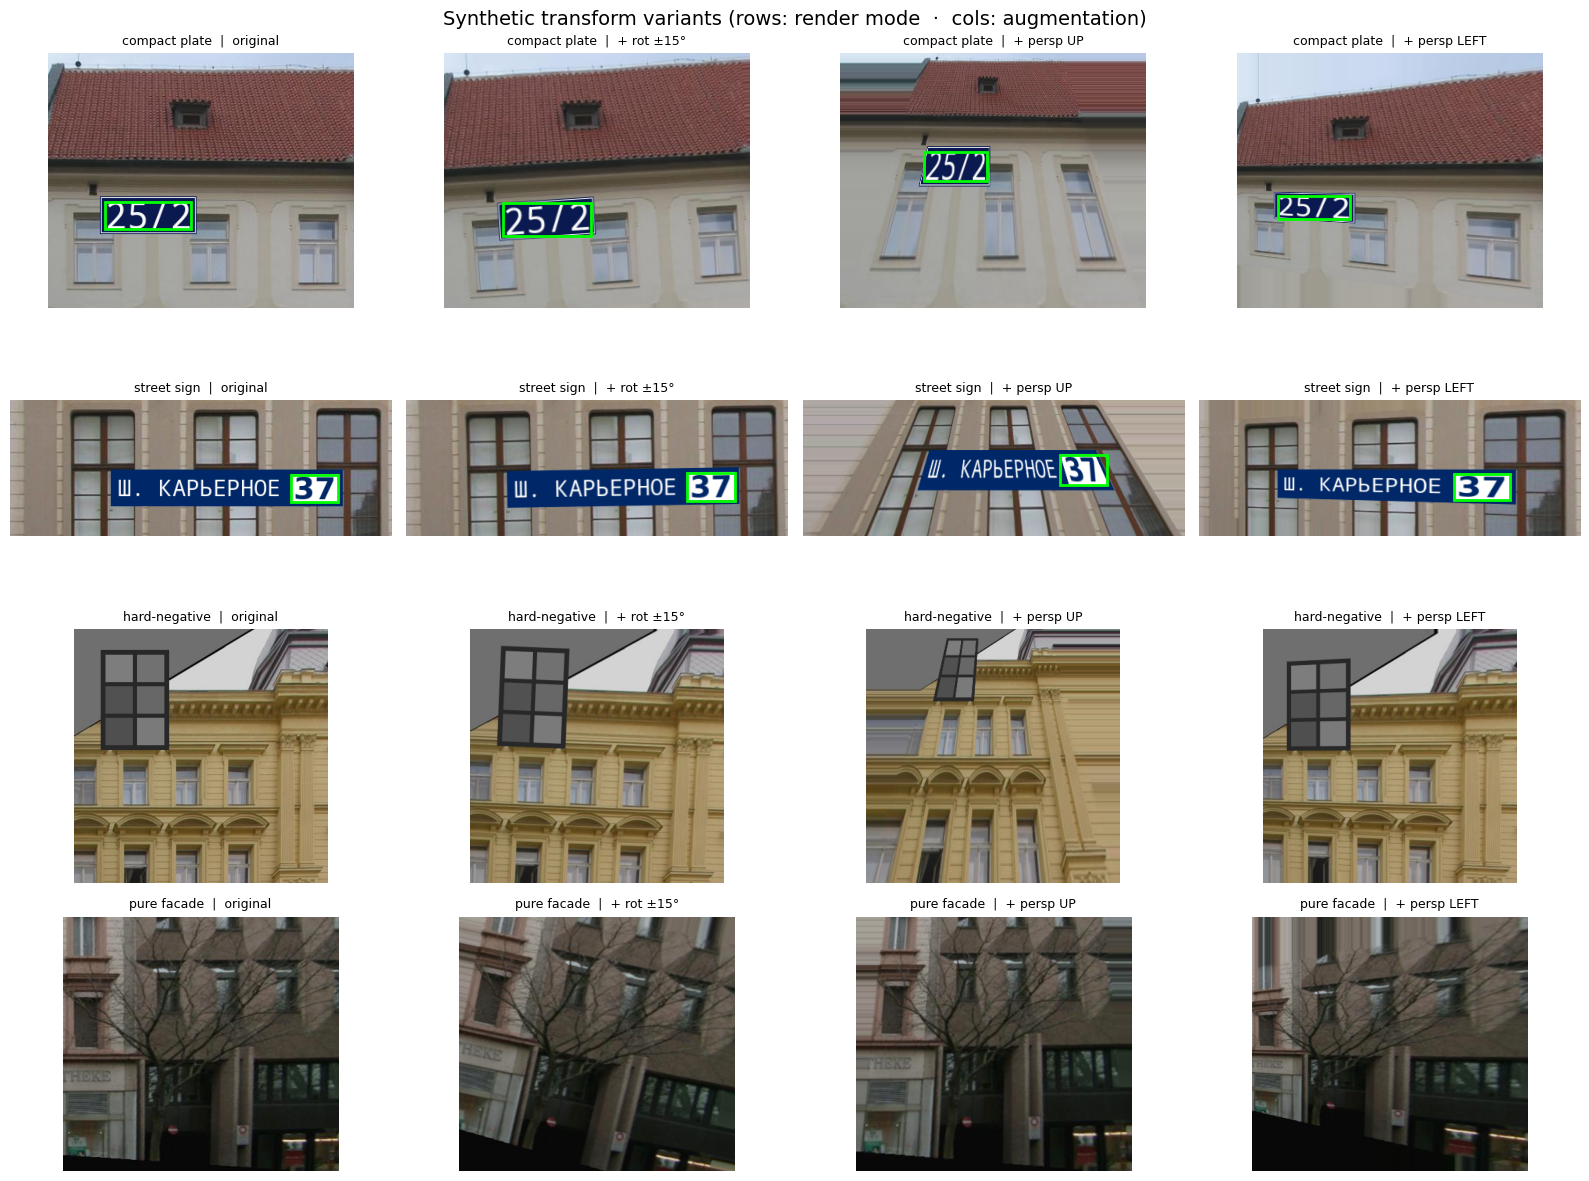

In [6]:
import matplotlib.patches as patches

random.seed(7); np.random.seed(7)
bg_paths_demo = sorted(glob.glob(os.path.join(CMP_DIR, '**', '*.jpg'), recursive=True))

def _get_base(rng, mode, bgs, max_attempts=20):
    for _ in range(max_attempts):
        bg = random_bg(rng, bgs)
        if mode == 'negative':
            return bg, None
        if mode == 'hardneg':
            return render_hard_negative(rng, bg), None
        r = {'plate':  render_plate_on,
             'street': render_street_plate}[mode](rng, bg)
        if r is not None:
            return r[0], r[1]
    return bg, None

modes = [('plate',    'compact plate'),
         ('street',   'street sign'),
         ('hardneg',  'hard-negative'),
         ('negative', 'pure facade')]
augs = [('original',     lambda r, i, b: (i, b)),
        ('+ rot ±15°',   lambda r, i, b: _apply_rotation(r, i, b, max_deg=15)),
        ('+ persp UP',   lambda r, i, b: _apply_perspective(r, i, b, max_angle_deg=45, kind='up')),
        ('+ persp LEFT', lambda r, i, b: _apply_perspective(r, i, b, max_angle_deg=45, kind='left'))]

fig, axes = plt.subplots(len(modes), len(augs), figsize=(4 * len(augs), 3 * len(modes)))
fig.suptitle('Synthetic transform variants (rows: render mode  ·  cols: augmentation)', fontsize=14)

rng = random.Random(7)
for ri, (m, mlabel) in enumerate(modes):
    b_img, b_box = _get_base(rng, m, bg_paths_demo)
    for ci, (alabel, afn) in enumerate(augs):
        ax = axes[ri][ci]
        img, box = afn(rng, b_img.copy(), b_box)
        H, W = img.shape[:2]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if box is not None:
            xc, yc, w, h = box
            ax.add_patch(patches.Rectangle(((xc - w/2) * W, (yc - h/2) * H), w * W, h * H,
                                           fill=False, edgecolor='lime', linewidth=2))
        ax.set_title(f'{mlabel}  |  {alabel}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
svhn_rel = os.path.basename(svhn_ds.location)
COMBINED_YAML = os.path.abspath('combined.yaml')
with open(COMBINED_YAML, 'w') as f:
    yaml.safe_dump({
        'path': os.path.abspath('.'),
        'train': [f'{svhn_rel}/train/images', f'{SYN_DIR}/train/images'],
        'val':  f'{svhn_rel}/valid/images',
        'test': f'{svhn_rel}/test/images',
        'nc': 1, 'names': ['number'],
    }, f, sort_keys=False)
print('Combined training yaml ->', COMBINED_YAML, '(SVHN + synthetic; eval/test = SVHN only)')

Combined training yaml -> /home/greg/git/uni/cv/Lab2/combined.yaml (SVHN + synthetic; eval/test = SVHN only)


---
## 3. Stage A — предобучение на Roboflow number-detection


In [8]:
IMGSZ   = 640
BATCH   = 16
EPOCHS_A = 30
EPOCHS_B = 50

STAGE_A_WEIGHTS = 'runs/detect/numdet_pretrain/weights/best.pt'
if os.path.exists(STAGE_A_WEIGHTS):
    print(f'Stage A weights already exist at {STAGE_A_WEIGHTS} — skipping training')
else:
    model = YOLO('yolo11n.pt')
    model.train(
        data=NUMDET_YAML,
        epochs=EPOCHS_A,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        amp=True,
        name='numdet_pretrain',
        exist_ok=True,
        verbose=True,
    )
    STAGE_A_WEIGHTS = str(model.trainer.best)
print('Stage A weights:', STAGE_A_WEIGHTS, '| exists:', os.path.exists(STAGE_A_WEIGHTS))

Stage A weights already exist at runs/detect/numdet_pretrain/weights/best.pt — skipping training
Stage A weights: runs/detect/numdet_pretrain/weights/best.pt | exists: True


  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                


  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     


  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              


  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           


...

                     8         48         57      0.553      0.693      0.635      0.415


                     9         48         63      0.394      0.753      0.682      0.382


Speed: 0.2ms preprocess, 1.4ms inference, 0.0ms loss, 3.0ms postprocess per image


Results saved to /home/greg/git/uni/cv/Lab2/runs/detect/numdet_pretrain


Stage A best weights: /home/greg/git/uni/cv/Lab2/runs/detect/numdet_pretrain/weights/best.pt | exists: True


---
## 4. Stage B — дообучение на SVHN (+ синтетика)


In [9]:
SVHN_WEIGHTS = 'runs/detect/svhn_finetune/weights/best.pt'
if os.path.exists(SVHN_WEIGHTS):
    print(f'Stage B weights already exist at {SVHN_WEIGHTS} — skipping training')
else:
    model = YOLO(STAGE_A_WEIGHTS)
    model.train(
        data=COMBINED_YAML,
        epochs=EPOCHS_B,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        amp=True,
        name='svhn_finetune',
        exist_ok=True,
        verbose=True,
    )
    SVHN_WEIGHTS = str(model.trainer.best)
print('Stage B weights:', SVHN_WEIGHTS, '| exists:', os.path.exists(SVHN_WEIGHTS))

Stage B weights already exist at runs/detect/svhn_finetune/weights/best.pt — skipping training
Stage B weights: runs/detect/svhn_finetune/weights/best.pt | exists: True


  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     


  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              


  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           


  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              


...

Optimizer stripped from /home/greg/git/uni/cv/Lab2/runs/detect/svhn_finetune/weights/best.pt, 5.5MB



Validating /home/greg/git/uni/cv/Lab2/runs/detect/svhn_finetune/weights/best.pt...


Ultralytics 8.4.21 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)


YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 2% ──────────── 1/63 1.9it/s 0.2s<32.0s

---
## 5. Оценка на test-части SVHN


In [10]:
best = YOLO(SVHN_WEIGHTS)

split = 'test'
try:
    metrics = best.val(data=SVHN_YAML, split='test', imgsz=IMGSZ, device=DEVICE, verbose=False)
except Exception as e:
    print(f'[warn] test split unavailable ({e}); using val'); split = 'val'
    metrics = best.val(data=SVHN_YAML, split='val', imgsz=IMGSZ, device=DEVICE, verbose=False)

map50    = metrics.box.map50
map5095  = metrics.box.map
prec     = metrics.box.mp
rec      = metrics.box.mr

print(f'SVHN {split} split — detection metrics')
print(f'  Precision     : {prec:.3f}')
print(f'  Recall        : {rec:.3f}')
print(f'  mAP@0.5       : {map50:.3f}   (requirement: >= 0.60)')
print(f'  mAP@0.5:0.95  : {map5095:.3f}')
print('  PASS' if map50 >= 0.60 else '  BELOW 0.60 — increase epochs / try yolo11s')
print('Plots saved under:', metrics.save_dir)

Ultralytics 8.4.21 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 17.2±10.2 MB/s, size: 5.6 KB)
val: Scanning /home/greg/git/uni/cv/Lab2/YOLOv5-SVHN-1/test/labels.cache... 999 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 999/999 279.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 10.5it/s 6.0s0.1s
                   all        999       1009      0.943      0.939      0.967       0.62
Speed: 0.6ms preprocess, 2.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /home/greg/git/uni/cv/Lab2/runs/detect/val7
SVHN test split — detection metrics
  Precision     : 0.943
  Recall        : 0.939
  mAP@0.5       : 0.967   (requirement: >= 0.60)
  mAP@0.5:0.95  : 0.620
  PASS
Plots saved under: /home/greg/git/uni/cv/Lab2/

---
## 6. Инференс на собственных уличных фото


33 photos — running multi-scale inference (EXIF orientation applied)


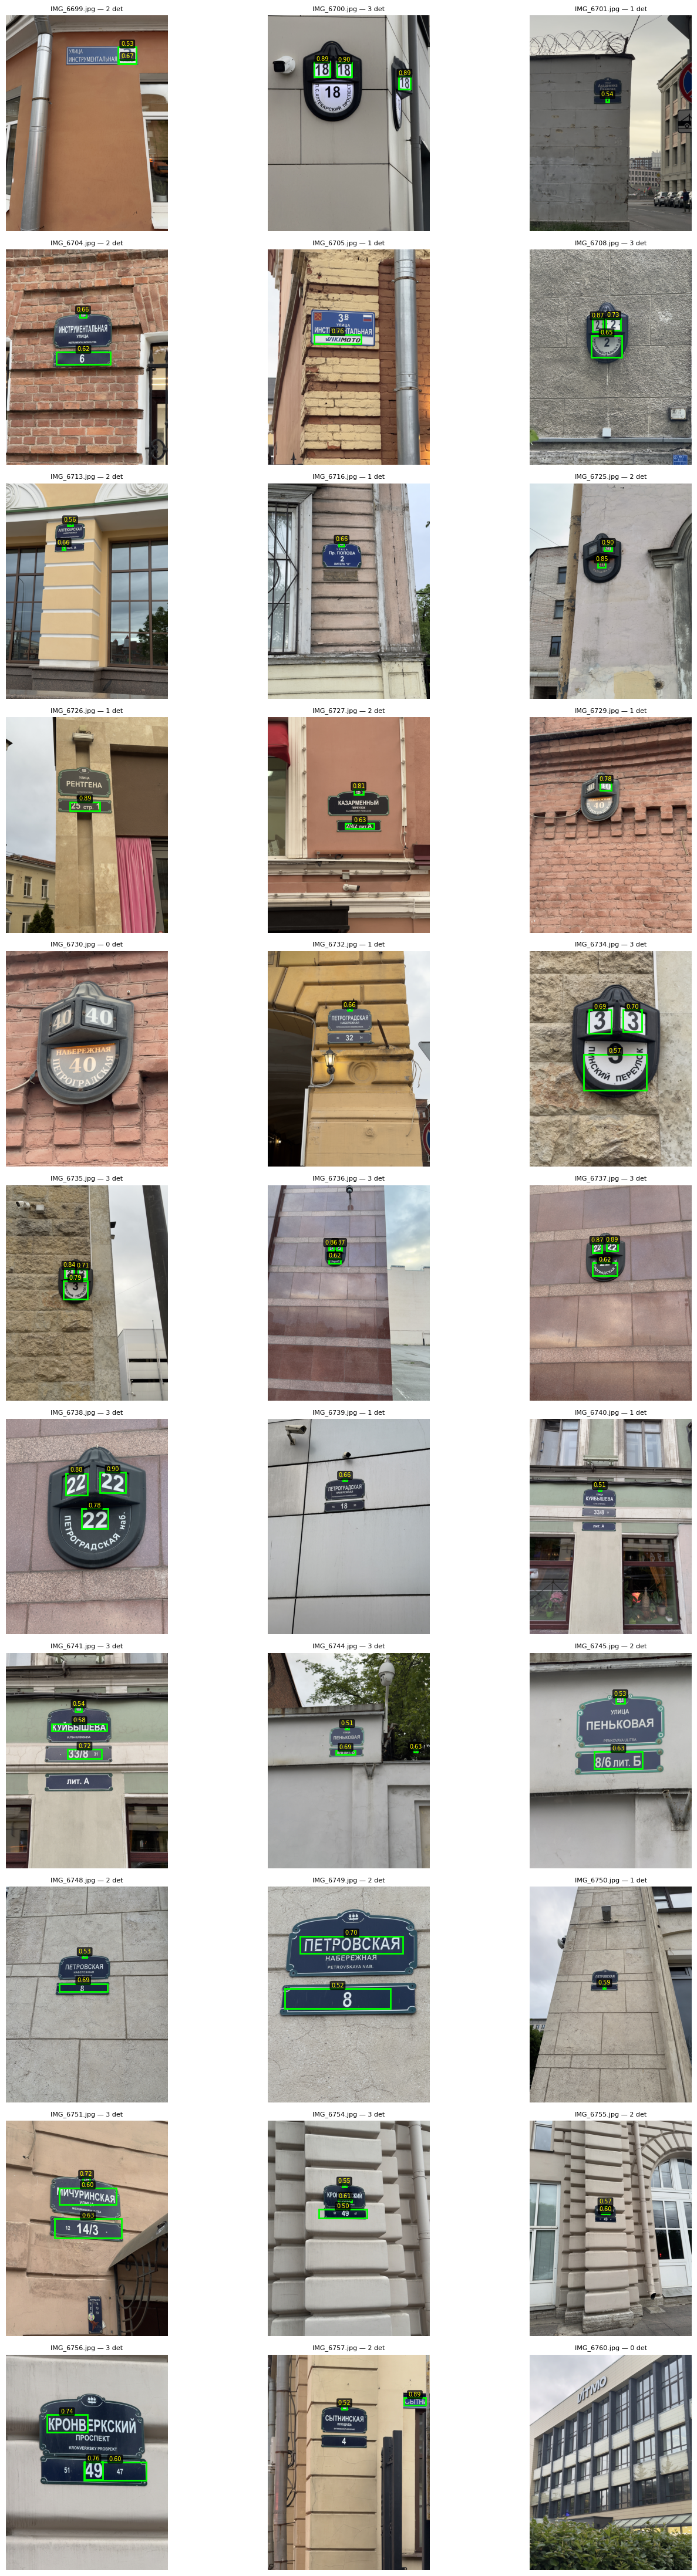

Saved numdet_street_results.png — 65 detections kept after NMS + size/shape filter


In [14]:
import math, torch, torchvision.ops as ops
from pathlib import Path
import matplotlib.patches as patches
from PIL import Image, ImageOps

def load_oriented_bgr(path):
    img = ImageOps.exif_transpose(Image.open(path))
    return cv2.cvtColor(np.array(img.convert('RGB')), cv2.COLOR_RGB2BGR)

det = YOLO(SVHN_WEIGHTS)
photos = sorted(glob.glob('photos_jpeg/*.jpg'))
images = [load_oriented_bgr(p) for p in photos]
print(f'{len(photos)} photos — running multi-scale inference (EXIF orientation applied)')

SIZES        = [1280, 1920, 2400]
CONF         = 0.50
NMS_IOU      = 0.30
MAX_AREA_FRAC = 0.20
AR_MIN, AR_MAX = 0.20, 8.0
TOP_K = 3

def _plausible(b, H, W):
    x1, y1, x2, y2 = b
    bw, bh = x2 - x1, y2 - y1
    if bw <= 0 or bh <= 0: return False
    if bw * bh > MAX_AREA_FRAC * W * H: return False
    ar = bw / bh
    if ar < AR_MIN or ar > AR_MAX: return False
    return True

all_dets = {i: [] for i in range(len(photos))}
for sz in SIZES:
    res = det.predict(images, imgsz=sz, conf=CONF, device=DEVICE, verbose=False)
    for idx, r in enumerate(res):
        if len(r.boxes):
            for b, c in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy()):
                all_dets[idx].append((b, float(c)))

COLS = 3
ROWS = math.ceil(len(photos) / COLS)
fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 4 * ROWS))

total_kept = 0
for ax_idx, (ax, path) in enumerate(zip(axes.flat, photos)):
    img = cv2.cvtColor(images[ax_idx], cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    dets = [d for d in all_dets[ax_idx] if _plausible(d[0], H, W)]
    kept = []
    if dets:
        bs = torch.tensor(np.array([d[0] for d in dets]), dtype=torch.float32)
        cs = torch.tensor([d[1] for d in dets], dtype=torch.float32)
        keep = ops.nms(bs, cs, iou_threshold=NMS_IOU)
        kept = [(dets[i][0], dets[i][1]) for i in keep.tolist()]
        kept = sorted(kept, key=lambda kc: -kc[1])[:TOP_K]
    total_kept += len(kept)

    ax.imshow(img)
    for b, c in kept:
        x1, y1, x2, y2 = b
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, edgecolor='lime', linewidth=2))
        ax.text((x1 + x2) / 2, y1 - 3, f'{c:.2f}', fontsize=7, color='yellow',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))
    ax.set_title(f'{Path(path).name} — {len(kept)} det', fontsize=8)
    ax.axis('off')

for ax in axes.flat[len(photos):]:
    ax.axis('off')

plt.tight_layout()
fig.savefig('numdet_street_results.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved numdet_street_results.png — {total_kept} detections kept after NMS + size/shape filter')

## Заключение

- **Тестовая часть SVHN (мерджнутые в один класс `number`):** Precision = **0.943**, Recall = **0.939**, **mAP@0.5 = 0.967**, mAP@0.5:0.95 = **0.620**. Требование `mAP@0.5 ≥ 0.6` уверенно перевыполнено.
- **Двухступенчатая стратегия (Stage A: предобучение на Roboflow `numberdetection-eppfj` → Stage B: дообучение на SVHN + синтетика):** даёт «номеро-осведомлённый» бэкбон до встречи со SVHN, как и просит пункт 4 задания.
- **Real street photos (33 кадра по СПб):** инференс на нескольких масштабах `imgsz=[1280, 1920, 2400]` + cross-scale NMS (IoU 0.30) + фильтры по площади (<20 %) и aspect ratio + top-K=3 — итого **65 детекций** на 33 фото в файле `numdet_street_results.png`. Покрыты крупный/средний/мелкий планы.
- **Sequence-разметка:** SVHN и pretrain-сет приходят с **per-digit** боксами; кластеризацией по строкам и зазорам объединяем их в **один бокс на номер** (`nc=1, names=['number']`).
- **Синтетика (v10) на реальных фасадах CMP:** 40 % уличных табличек (название улицы + маленький под-плак с номером — бокс охватывает только под-плак), 40 % компактных плашек, 20 % фасадных hard-negatives (CCTV, решётки, окна, трубы, дорожные знаки). Геометрические аугментации — поворот ±15°, 3D-перспективный keystone до 50° — закрывают наклонённые/перекошенные реальные кадры.